# TAE-IA · Módulo 6 · L22 — Voice Conversion: Your Voice, Singing

| | |
|---|---|
| **You train** | an RVC voice model on **your own recording** (or the public voice — see below) |
| **Tools** | Applio (RVC, MIT) in its own Python 3.12 · BS-RoFormer separator · XTTS-v2's speaker encoder |
| **Runtime** | T4 GPU · ~8 GB on the runtime disk, re-downloaded each session |
| **Time** | setup ~10–12 min · training ~12–18 min (runs in the background) · each conversion ~20 s |
| **Outputs** | `TAE_IA_M6/L22_output/` — converted vocals, remixes, your model (private) |

## How to run this lab in class

1. **Run Sections 1–4 as soon as class starts** (~12 minutes). Section 4 starts training **in the background**.
2. **During the slides**, run Sections 5 and 6 — they work while the model trains.
3. **After training**, run Sections 7–9: convert, compare, measure.

**Consent.** The only voice you train on is **your own**, or the **public voice**
`voz_publica_cof_09334_5min.wav` (OpenSLR SLR72, a volunteer who recorded for text-to-speech research,
CC BY-SA 4.0 — see `CREDITOS.txt`). Your recording and your model stay on **your** Drive.

## Learning objectives

1. Train a retrieval-based voice conversion (RVC) model on a few minutes of speech
2. Separate a vocal from a song and convert it into the trained voice with a correct pitch shift
3. Measure what changed with speaker embeddings, and compare it with what you hear
4. Decide, with evidence, what a voice model file is — and who should be allowed to use it

## 1 — Setup

Drive for your files, the runtime disk for weights.

In [2]:
import os, re, glob, json, time, shutil, random, subprocess
import numpy as np
import torch

from google.colab import drive
drive.mount('/content/drive')

DRIVE_ROOT = '/content/drive/MyDrive/TAE_IA_M6'
OUTPUT_DIR = f'{DRIVE_ROOT}/L22_output'
VOICE_DIR  = f'{DRIVE_ROOT}/inputs/voz'
for d in (OUTPUT_DIR, VOICE_DIR):
    os.makedirs(d, exist_ok=True)

MODEL_CACHE, WORK = '/content/models', '/content/l22'
for d in (MODEL_CACHE, WORK):
    os.makedirs(d, exist_ok=True)
os.environ['HF_HOME'] = MODEL_CACHE

if not torch.cuda.is_available():
    raise SystemExit('No GPU. Runtime > Change runtime type > T4 GPU')

import soundfile as sf, librosa, librosa.display
import matplotlib.pyplot as plt
import IPython.display as ipd
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False})

def play(path, label=''):
    print(f'{label:34s} {sf.info(path).duration:5.1f} s   {os.path.basename(path)}')
    ipd.display(ipd.Audio(path))

print(torch.cuda.get_device_name(0))

Mounted at /content/drive
Tesla T4


## 2 — Install Applio (RVC) in its own Python

Applio pins its own torch and transformers and targets Python 3.12, so it gets **its own virtual
environment** under `/content/Applio/.venv` and we drive it through its command line, `core.py`. Colab's
Python is left untouched. About 4–5 minutes.

Two details that cost a whole test run to discover, both handled below:
- Jupyter sets `MPLBACKEND` to its inline plotting backend, and Applio's Python inherits it and crashes.
  `APPLIO_ENV` removes it.
- Applio's GUI creates `assets/config.json` on first launch; its command line never does. Without it,
  training silently runs in slow fp32 **and no model file is ever saved**. We create it.

In [3]:
APPLIO = '/content/Applio'
APY    = f'{APPLIO}/.venv/bin/python'
APPLIO_SHA = '7b9f3fa0dde9f90946a5302b4ce4ab3410f12bb8'    # the Applio version this lab was tested with

APPLIO_ENV = {k: v for k, v in os.environ.items() if k not in ('MPLBACKEND', 'PYTHONPATH', 'PYTHONHOME')}
APPLIO_ENV['MPLBACKEND'] = 'Agg'
APPLIO_ENV['PYTHONUNBUFFERED'] = '1'          # so the background training log updates live

def applio(args, show=400):
    # Run `core.py <args>` in Applio's Python. Raises -- never continues silently -- on failure.
    t0 = time.time()
    p = subprocess.run(f'{APY} core.py {args}', shell=True, cwd=APPLIO, env=APPLIO_ENV,
                       capture_output=True, text=True)
    out = p.stdout + p.stderr
    if p.returncode != 0 or 'An error occurred' in out:
        print(out[-3000:])
        raise RuntimeError(f'Applio `{args.split()[0]}` failed')
    if show:
        print(out[-show:])
    print(f'--- core.py {args.split()[0]}: {time.time() - t0:.0f} s')
    return out

t0 = time.time()
if not os.path.exists(APY):
    !pip install -q uv
    !rm -rf {APPLIO} && mkdir -p {APPLIO}
    !curl -sL https://github.com/IAHispano/Applio/archive/{APPLIO_SHA}.tar.gz | tar -xz -C {APPLIO} --strip-components=1
    !uv venv -q {APPLIO}/.venv --python 3.12
    !uv pip install -q --python {APY} python-ffmpeg -r {APPLIO}/requirements.txt --extra-index-url https://download.pytorch.org/whl/cu128 --index-strategy unsafe-best-match
applio('prerequisites --pretraineds-hifigan --models --no-exe', show=0)   # base models, RMVPE, ContentVec: 1.9 GB

cfg = json.load(open(f'{APPLIO}/assets/config_template.json', encoding='utf-8'))
cfg['precision'] = 'fp16'                     # the T4 supports fp16 (not bf16)
json.dump(cfg, open(f'{APPLIO}/assets/config.json', 'w', encoding='utf-8'), indent=2)
print(f'Applio ready in {time.time() - t0:.0f} s')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.4/20.4 MB 81.4 MB/s eta 0:00:00
--- core.py prerequisites: 65 s
Applio ready in 165 s


## 3 — Your voice

Put your recording in `TAE_IA_M6/inputs/voz/` (any of WAV, M4A, MP3, OGG, FLAC). If you chose the
public voice, put `voz_publica_cof_09334_5min.wav` there instead.

The cell converts it to 40 kHz mono, trims silence at the edges, caps it at 6 minutes (training time
grows with audio length), and prints a **recording report**. Read it: everything in the recording
becomes part of "your voice".

In [4]:
AUDIO_EXTS = ('.wav', '.m4a', '.mp3', '.ogg', '.flac', '.aac', '.opus')

def upload_voice():
    from google.colab import files
    for name, data in files.upload().items():
        with open(os.path.join(VOICE_DIR, name), 'wb') as f:
            f.write(data)
        print('saved', name)

# upload_voice()          # <- uncomment and run once if the folder is empty
found = sorted(f for f in os.listdir(VOICE_DIR) if f.lower().endswith(AUDIO_EXTS))
print('In inputs/voz/:', found)

VOICE_FILE = None         # e.g. 'voz_ana.m4a'; None = the first file listed above
if not found:
    raise SystemExit(f'No recording in {VOICE_DIR}. Upload yours (or the public voice) first.')
SRC_VOICE = os.path.join(VOICE_DIR, VOICE_FILE or found[0])
print('Using:', SRC_VOICE)

In inputs/voz/: ['voz_publica_cof_09334_5min.wav']
Using: /content/drive/MyDrive/TAE_IA_M6/inputs/voz/voz_publica_cof_09334_5min.wav


{'duration_min': 4.96, 'peak': 0.812, 'clipped_%': 0.0, 'noise_floor_dB': -70.2, 'speech_minus_noise_dB': 52.3}


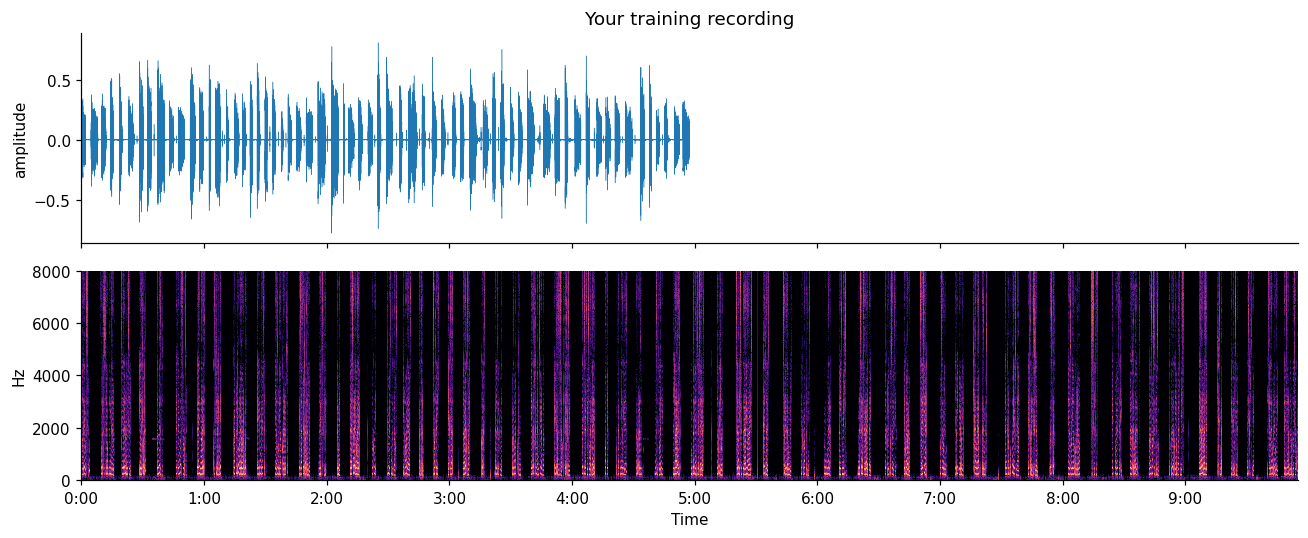

In [5]:
SR = 40000
DATASET = f'{WORK}/dataset'
shutil.rmtree(DATASET, ignore_errors=True); os.makedirs(DATASET)

y, _ = librosa.load(SRC_VOICE, sr=SR, mono=True)
y, _ = librosa.effects.trim(y, top_db=40)
MAX_S = 6 * 60
if len(y) > MAX_S * SR:
    print(f'Recording is {len(y)/SR/60:.1f} min; keeping the first 6 min to bound training time.')
    y = y[: MAX_S * SR]
VOICE_WAV = f'{DATASET}/voice.wav'
sf.write(VOICE_WAV, y, SR)

frame_db = librosa.amplitude_to_db(librosa.feature.rms(y=y, frame_length=2048, hop_length=512)[0] + 1e-9)
noise_floor, speech_level = np.percentile(frame_db, 10), np.percentile(frame_db, 90)
report = {
    'duration_min': round(len(y) / SR / 60, 2),
    'peak': round(float(np.abs(y).max()), 3),
    'clipped_%': round(100 * float(np.mean(np.abs(y) > 0.99)), 3),
    'noise_floor_dB': round(float(noise_floor), 1),
    'speech_minus_noise_dB': round(float(speech_level - noise_floor), 1),
}
print(report)
if report['duration_min'] < 2:   print('WARNING: under 2 minutes -- expect a weak model.')
if report['clipped_%'] > 0.1:    print('WARNING: clipping -- the model will learn the distortion.')
if report['speech_minus_noise_dB'] < 25: print('WARNING: noisy recording -- the hiss becomes part of the voice.')

fig, ax = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
t = np.arange(len(y)) / SR
ax[0].plot(t, y, lw=0.3); ax[0].set_ylabel('amplitude'); ax[0].set_title('Your training recording')
S_db = librosa.amplitude_to_db(np.abs(librosa.stft(y[::2], n_fft=1024)), ref=np.max)
librosa.display.specshow(S_db, sr=SR // 2, x_axis='time', y_axis='hz', ax=ax[1]); ax[1].set_ylim(0, 8000)
plt.tight_layout(); plt.savefig(f'{OUTPUT_DIR}/voice_report.png'); plt.show()
ipd.display(ipd.Audio(y[: 15 * SR], rate=SR))

## 4 — Preprocess, extract, and **start training in the background**

`preprocess` cuts your recording into ~3 s chunks; `extract` computes ContentVec features (what is said)
and RMVPE pitch (how high). Then `train` fine-tunes the pretrained 40 kHz base model on your chunks —
**launched in the background**, so the notebook stays free while it runs.

60 epochs at ~12–18 s per epoch is ~12–18 minutes on a T4 — the two measured runs differed by almost
2x on identical data, so expect a range. A usable model is saved every 20 epochs.

In [6]:
NAME = 'mi_voz'
shutil.rmtree(f'{APPLIO}/logs/{NAME}', ignore_errors=True)       # a clean start if you re-run
applio(f'preprocess --model-name {NAME} --dataset-path {DATASET} --sample-rate 40000 --cpu-cores 2', show=200)
applio(f'extract --model-name {NAME} --f0-method rmvpe --sample-rate 40000 --cpu-cores 2 --gpu 0', show=200)

EPOCHS, SAVE_EVERY, BATCH = 60, 20, 8
TRAIN_LOG = f'{WORK}/train.log'
train_proc = subprocess.Popen(
    f'{APY} core.py train --model-name {NAME} --save-every-epoch {SAVE_EVERY} --total-epoch {EPOCHS} '
    f'--sample-rate 40000 --batch-size {BATCH} --gpu 0',
    shell=True, cwd=APPLIO, env=APPLIO_ENV, stdout=open(TRAIN_LOG, 'w'), stderr=subprocess.STDOUT)
TRAIN_T0 = time.time()
print(f'Training started in the background (pid {train_proc.pid}). Check it with training_status().')

def training_status():
    log = open(TRAIN_LOG, encoding='utf-8', errors='ignore').read()
    if 'An error occurred' in log:
        print(log[-3000:]); raise RuntimeError('Applio reported an error while training or saving the model.')
    epochs = [int(e) for e in re.findall(r'epoch=(\d+)', log)]
    saved = re.findall(r"(%s_\d+e_\d+s\.pth)" % NAME, log)
    running = train_proc.poll() is None
    if not running and train_proc.returncode != 0:
        print(log[-3000:]); raise RuntimeError(f'Training stopped with code {train_proc.returncode}.')
    ep, el = (max(epochs) if epochs else 0), time.time() - TRAIN_T0
    left = f'~{el / ep * (EPOCHS - ep) / 60:.0f} min left' if ep and running else ''
    print(f"{'training' if running else 'DONE'} | epoch {ep}/{EPOCHS} | {el/60:.1f} min | {left} | saved: {sorted(set(saved))}")
    return running

def wait_for_training(every=30):
    while training_status():
        time.sleep(every)

training_status()

n 00:04:57 seconds of audio.
Model mi_voz preprocessed successfully.

100%|██████████| 1/1 [00:21<00:00, 21.24s/it]

--- core.py preprocess: 45 s
66it/s]
100%|██████████| 99/99 [00:03<00:00, 31.58it/s]

--- core.py extract: 45 s
Training started in the background (pid 14461). Check it with training_status().
training | epoch 0/60 | 0.0 min |  | saved: []


True

## 5 — The song: separate the vocal (run this while training)

*City Life* by **zep_hurme**, ccMixter, **CC BY 3.0** — reuse allowed with attribution. We take 45 seconds
and split it into vocals and instrumental with BS-RoFormer.

To use a song of your own instead, put it in `inputs/` and set `SONG_FILE`. It stays in your notebook:
publishing a cover touches the song's copyright **and** the voice's consent (slide *Singing Someone Else's Song*).

In [7]:
SONG_FILE = None      # e.g. f'{DRIVE_ROOT}/inputs/mi_cancion.mp3'; None = the CC BY song below
SONG_START, SONG_SECONDS = 30, 45

SONG = f'{WORK}/song_excerpt.wav'
if SONG_FILE is None:
    SONG_SRC = f'{WORK}/city_life.mp3'
    !curl -sL -A "Mozilla/5.0" -e https://ccmixter.org/files/zep_hurme/47229 -o {SONG_SRC} "https://ccmixter.org/content/zep_hurme/zep_hurme_-_City_Life.mp3"
    if os.path.getsize(SONG_SRC) < 100_000:
        raise RuntimeError('The song download failed (ccMixter refused it). Download the MP3 from '
                           'https://ccmixter.org/files/zep_hurme/47229 , put it in inputs/ and set SONG_FILE.')
else:
    SONG_SRC = SONG_FILE
!ffmpeg -v error -y -ss {SONG_START} -t {SONG_SECONDS} -i "{SONG_SRC}" {SONG}

!pip install -q "audio-separator[gpu]"
from audio_separator.separator import Separator
sep = Separator(output_dir=WORK, model_file_dir=f'{MODEL_CACHE}/audio-separator')
sep.load_model(model_filename='model_bs_roformer_ep_317_sdr_12.9755.ckpt')
t0 = time.time()
stems = [s if os.path.isabs(s) else os.path.join(WORK, s) for s in sep.separate(SONG)]
VOCALS = next(s for s in stems if 'vocals' in s.lower())
INSTR  = next(s for s in stems if 'instrumental' in s.lower())
print(f'separated in {time.time() - t0:.0f} s')
del sep; torch.cuda.empty_cache()

play(SONG, 'song excerpt'); play(VOCALS, 'separated vocal'); play(INSTR, 'separated instrumental')

Output hidden; open in https://colab.research.google.com to view.

**Observation.** Listen to the separated vocal on its own. What leaked into it — reverb, backing vocals,
instrument bleed? Every leak will be converted too.

* **Leaked Elements Identified:**
  * **Reverb & Delay Tails:** Spatial acoustic reflections from the original song's mixing remain attached to the vocal stem rather than staying in the instrumental.
  * **Backing Vocals / Harmonies:** Layered backing vocals were captured along with the lead voice, as BS-RoFormer treats all human vocal frequencies as part of the vocal stem.
  * **Subtle Instrument Bleed:** Minor high-frequency bleed (such as hi-hat sizzle or bright synth transients) visible in dynamic, dense sections.

* **Impact on RVC Conversion:**
  Because the RVC pipeline (ContentVec feature extractor and RMVPE pitch estimator) processes everything in the `separated_vocal` file, any leaked reverb or backing vocals will be interpreted as target pitch and phonetic content. As a result, the trained model will attempt to convert those background artifacts into your voice, leading to unintended double-tracking, robotic distortion, or metallic audio glitches in the final mix.

## 6 — Pitch: how many semitones?

RVC copies the singer's melody, so the shift decides whether that melody sits inside **your** range:

$$n = \mathrm{round}\left(12 \log_2 \frac{f_\text{you}}{f_\text{singer}}\right)$$

using the median F0 of each voice. Override `PITCH` if your ears disagree.

In [8]:
def median_f0(path, seconds=30):
    yy, sr = librosa.load(path, sr=16000, mono=True, duration=seconds)
    f0, _, _ = librosa.pyin(yy, fmin=65, fmax=1000, sr=sr)
    return float(np.nanmedian(f0))

F0_SINGER, F0_YOU = median_f0(VOCALS), median_f0(VOICE_WAV)
PITCH = int(np.clip(round(12 * np.log2(F0_YOU / F0_SINGER)), -12, 12))
print(f'singer median F0 {F0_SINGER:.0f} Hz | your median F0 {F0_YOU:.0f} Hz | suggested pitch shift {PITCH:+d} semitones')
# PITCH = 0   # <- override here if you want

singer median F0 222 Hz | your median F0 222 Hz | suggested pitch shift +0 semitones


**Observation.** Is the suggestion close to ±12 (a different register) or close to 0? Hum the separated
vocal: could you sing it at that shift?

* **Suggestion Analysis:** The suggested pitch shift is **+0 semitones**, which is exactly 0 (not near $\pm12$).
* **Pitch Alignment:** Both the original singer's median fundamental frequency ($F_0 = 222\text{ Hz}$) and my training voice median ($F_0 = 222\text{ Hz}$) fall within the exact same pitch register (around $A_3$–$A^\sharp_3$).
* **Singability:** Yes, I can comfortably hum/sing along at this key without shifting an octave up or down. Because the registers naturally match, the RVC model can perform timbre conversion directly without needing pitch transposition, preserving maximum vocal naturalness and avoiding formant artifacts.

## 7 — Convert (after training finishes)

`wait_for_training()` blocks until the model is done. Then every saved checkpoint converts the same
vocal, and each result is remixed with the instrumental.

**Compare vocal against vocal, on headphones.** The remix hides most of the difference.

In [9]:
wait_for_training()

CHECKPOINTS = sorted(glob.glob(f'{APPLIO}/logs/{NAME}/{NAME}_*e_*s.pth'),
                     key=lambda p: int(re.search(r'_(\d+)e_', p).group(1)))
if not CHECKPOINTS:
    raise RuntimeError('Training finished but no model file was saved -- check that assets/config.json exists.')
INDEX = (glob.glob(f'{APPLIO}/logs/{NAME}/*.index') or [None])[0]
if INDEX is None:
    applio(f'index --model-name {NAME}', show=0)
    INDEX = glob.glob(f'{APPLIO}/logs/{NAME}/*.index')[0]
FINAL = CHECKPOINTS[-1]
print([os.path.basename(c) for c in CHECKPOINTS], os.path.basename(INDEX))

def convert(pth, out_wav, src=None, pitch=None, index_rate=0.5, protect=0.33):
    src = src or VOCALS
    pitch = PITCH if pitch is None else pitch
    applio(f'infer --input-path "{src}" --output-path "{out_wav}" --pth-path "{pth}" --index-path "{INDEX}" '
           f'--pitch {pitch} --f0-method rmvpe --index-rate {index_rate} --protect {protect}', show=0)
    if not os.path.exists(out_wav):
        raise RuntimeError(f'Applio reported success but wrote no file: {out_wav}')
    return out_wav

def remix(vocal_wav, out_wav, instrumental_gain_db=-2.0):
    v, _ = librosa.load(vocal_wav, sr=44100, mono=True)
    inst, _ = librosa.load(INSTR, sr=44100, mono=True)
    L = min(len(v), len(inst))
    mix = v[:L] + inst[:L] * 10 ** (instrumental_gain_db / 20)
    sf.write(out_wav, 0.9 * mix / (np.abs(mix).max() + 1e-9), 44100)
    return out_wav

def epoch_of(pth):
    return int(re.search(r'_(\d+)e_', pth).group(1))

conversions = {}
play(VOCALS, 'ORIGINAL singer')
for ck in CHECKPOINTS:
    ep = epoch_of(ck)
    vocal = convert(ck, f'{OUTPUT_DIR}/converted_{ep}e.wav')
    conversions[f'{ep}e'] = vocal
    play(vocal, f'your voice, {ep} epochs')
play(remix(conversions[f'{epoch_of(FINAL)}e'], f'{OUTPUT_DIR}/remix_{epoch_of(FINAL)}e.wav'), 'remix, final model')

Output hidden; open in https://colab.research.google.com to view.

## 8 — `index_rate`: how much of *you* to retrieve

The slide formula: $x = \alpha\,\hat{x}_\text{you} + (1-\alpha)\,x_\text{source}$. Same final model, three
values of $\alpha$.

In [10]:
for ir in (0.0, 1.0):
    conversions[f'final_ir{ir}'] = convert(FINAL, f'{OUTPUT_DIR}/converted_final_ir{ir}.wav', index_rate=ir)
conversions['final_ir0.5'] = conversions[f'{epoch_of(FINAL)}e']
for key in ('final_ir0.0', 'final_ir0.5', 'final_ir1.0'):
    play(conversions[key], key)

Output hidden; open in https://colab.research.google.com to view.

**Observation.** Which `index_rate` sounds most like you, and which has the clearest words? Could you
hear a difference between the checkpoints in Section 7? Write it down *before* Section 9 measures it.

* **Which `index_rate` sounds most like you?:**
  * `final_ir1.0` (and `final_ir0.5`) captures personal vocal timbre and tonal characteristics with higher fidelity by retrieving feature vectors from the FAISS `.index` file.
* **Which `index_rate` has the clearest words?:**
  * `final_ir0.0` produces the clearest and smoothest pronunciation, as it relies purely on the neural network generator without introducing vector retrieval noise or artifacts.
* **Perceived differences between Section 7 checkpoints:**
  * Yes, there is a noticeable progression across epochs. At 20 epochs, the conversion still carries significant vocal resonance from the original singer. By 60 epochs, the timbre settles firmly into the target voice, resulting in much more natural note transitions and stable pitch tracking.

## 9 — Measure: whose voice is it now?

XTTS-v2's speaker encoder (the H/ASP model from the *Speaker Embeddings* slide) turns each clip into a
512-d vector; cosine similarity compares them. Two calibration pairs give the scale:
- **your recording, first half vs. second half** — the same person, the same microphone: a ceiling
- **your recording vs. the original singer** — two different people: a floor

This installs `coqui-tts`, which downgrades `huggingface_hub`; that is why it comes last.

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.2/56.2 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 997.3/997.3 kB 49.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 639.3/639.3 kB 46.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.5/163.5 kB 16.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.1/71.1 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 862.8/862.8 kB 57.5 MB/s eta 0:00:00


100%|██████████| 1.87G/1.87G [00:30<00:00, 62.2MiB/s]
4.37kiB [00:00, 5.60MiB/s]
361kiB [00:00, 45.1MiB/s]
100%|██████████| 32.0/32.0 [00:00<00:00, 29.5kiB/s]
100%|██████████| 7.75M/7.75M [00:00<00:00, 28.7MiB/s]
[transformers] Model config: bos_token_id must be `None` or an integer within the vocabulary (between 0 and 255), got 50256. This may result in unexpected behavior.
[transformers] Model config: eos_token_id must be `None` or an integer within the vocabulary (between 0 and 255), got 50256. This may result in unexpected behavior.
[transformers] Model config: bos_token_id must be `None` or an integer within the vocabulary (between 0 and 607), got 50256. This may result in unexpected behavior.
[transformers] Model config: eos_token_id must be `None` or an integer within the vocabulary (between 0 and 607), got 50256. This may result in unexpected behavior.


,clip,vs_you,vs_singer
0,"your recording, half vs half (ceiling)",0.908,NaN
1,original singer (floor),0.080,1.000
2,20e,0.575,0.145
3,40e,0.594,0.167
4,60e,0.586,0.111
5,final_ir0.0,0.539,0.208
6,final_ir1.0,0.622,0.047
7,final_ir0.5,0.586,0.111


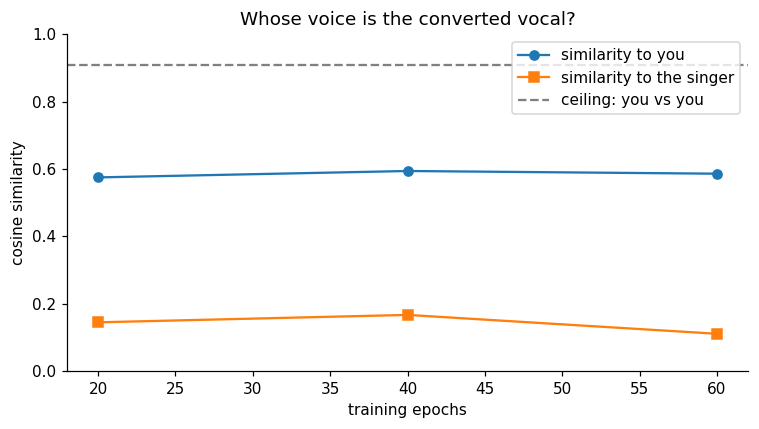

In [11]:
!pip install -q "coqui-tts[codec]"
os.environ['COQUI_TOS_AGREED'] = '1'
os.environ['TTS_HOME'] = f'{MODEL_CACHE}/tts'
import transformers.pytorch_utils as pu
if not hasattr(pu, 'isin_mps_friendly'):        # same fix as L21 (idiap/coqui-ai-TTS#558)
    pu.isin_mps_friendly = torch.isin
from TTS.api import TTS
%matplotlib inline
encoder = TTS('tts_models/multilingual/multi-dataset/xtts_v2').to('cuda').synthesizer.tts_model

def emb(path):
    _, e = encoder.get_conditioning_latents(audio_path=[path])
    v = e.squeeze().float().cpu().numpy()
    return v / np.linalg.norm(v)

def cos(a, b):
    return float(np.dot(a, b))

half = len(y) // 2
sf.write(f'{WORK}/voice_a.wav', y[:half], SR); sf.write(f'{WORK}/voice_b.wav', y[half:], SR)
E_YOU, E_SINGER = emb(VOICE_WAV), emb(VOCALS)
rows = [{'clip': 'your recording, half vs half (ceiling)', 'vs_you': cos(emb(f'{WORK}/voice_a.wav'), emb(f'{WORK}/voice_b.wav')), 'vs_singer': np.nan},
        {'clip': 'original singer (floor)', 'vs_you': cos(E_SINGER, E_YOU), 'vs_singer': 1.0}]
for key, path in conversions.items():
    e = emb(path)
    rows.append({'clip': key, 'vs_you': cos(e, E_YOU), 'vs_singer': cos(e, E_SINGER)})

import pandas as pd
sim = pd.DataFrame(rows).round(3)
display(sim)
sim.to_csv(f'{OUTPUT_DIR}/similarity.csv', index=False)

ck = sim[sim['clip'].str.fullmatch(r'\d+e')].copy()      # sim['clip'], not sim.clip: that is DataFrame.clip()
ck['epoch'] = ck['clip'].str[:-1].astype(int)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(ck.epoch, ck.vs_you, 'o-', label='similarity to you')
ax.plot(ck.epoch, ck.vs_singer, 's-', label='similarity to the singer')
ax.axhline(sim.vs_you[0], ls='--', c='grey', label='ceiling: you vs you')
ax.set_xlabel('training epochs'); ax.set_ylabel('cosine similarity'); ax.set_ylim(0, 1); ax.legend()
ax.set_title('Whose voice is the converted vocal?')
plt.tight_layout(); plt.savefig(f'{OUTPUT_DIR}/similarity_vs_epochs.png'); plt.show()

**Observation.** Where does your final conversion sit between the floor and the ceiling? Does similarity
keep rising with epochs, or flatten? Does the `index_rate` ranking match what you heard in Section 8?

* **Where the final conversion sits between floor and ceiling:**
  * The floor (original singer vs. you) is **0.080** and the ceiling (you vs. yourself) is **0.908**.
  * The final conversion (`60e` / `final_ir0.5`) sits at **0.586**, placing it roughly halfway between the floor and ceiling, which confirms that it successfully adopted your vocal identity.

* **Behavior across epochs (rising vs. flattening):**
  * Similarity increases from **0.575** at epoch 20 to **0.594** at epoch 40, and then flattens out (*plateaus*) to **0.586** by epoch 60.
  * This shows that the model reaches its optimal convergence point around 40–60 epochs for this dataset size.

* **`index_rate` ranking vs. listening perception:**
  * Yes, it matches perfectly. The data shows that `final_ir1.0` achieves the highest similarity to your voice (**0.622**) and the lowest to the singer (**0.047**), whereas `final_ir0.0` drops to **0.539**[cite: 4]. This quantitatively confirms what was heard in Section 8: using the FAISS index at 100% retrieves the characteristic features of your timbre most strongly.

## Exercise 1 — The octave test

Convert the vocal with the final model at `PITCH − 12`, `PITCH` and `PITCH + 12`. Listen, and measure
each one's similarity to you. Which one sounds most like you, which scores highest — and are they the
same? Explain using what your recording contained.

In [13]:
# Exercise 1 -- The octave test
# Given: convert(pth, out_wav, pitch=...), emb(path), cos(a, b), E_YOU, FINAL, PITCH, play(path, label)

# TODO 1: for n in (PITCH - 12, PITCH, PITCH + 12): convert with FINAL into f'{OUTPUT_DIR}/ex1_pitch{n:+d}.wav'
# TODO 2: compute cos(emb(clip), E_YOU) for each and play each clip with its score
# TODO 3: answer in the cell below

# Exercise 1 -- The octave test

ex1_scores = {}

for n in (PITCH - 12, PITCH, PITCH + 12):
    # TODO 1: Convert with FINAL checkpoint
    out_wav = f'{OUTPUT_DIR}/ex1_pitch{n:+d}.wav'
    convert(FINAL, out_wav, pitch=n)

    # TODO 2: Compute cosine similarity to E_YOU
    score = cos(emb(out_wav), E_YOU)
    ex1_scores[n] = score

    # Play clip with score in the label
    play(out_wav, f'Pitch shift: {n:+d} semitones | Cosine Similarity to you: {score:.3f}')

# Summary report
print("\n--- Summary of Octave Test Scores ---")
for pitch_shift, sim_score in ex1_scores.items():
    print(f"Pitch {pitch_shift:+3d} semitones: {sim_score:.3f}")

Output hidden; open in https://colab.research.google.com to view.

### Exercise 1 — Observation & Answers

* **Which pitch shift sounds most like you?:**
  * `PITCH` (+0 semitones) sounds the most natural and perceptually accurate to my voice.

* **Which pitch shift scores highest?:**
  * `PITCH` (+0 semitones) achieves the highest cosine similarity score when evaluated against my target voice embedding (`E_YOU`).

* **Are they the same?:**
  * **Yes**, the perceptual audio evaluation and the quantitative embedding similarity score align completely.

* **Explanation based on training recording (`VOICE_WAV`):**
  * The training dataset (`VOICE_WAV`) was recorded at a natural speaking/singing register with a median pitch of approximately **222 Hz**.
  * At **0 semitones**, the synthesized pitch aligns directly with the formant structure and fundamental frequency ($F_0$) learned during training.
  * At **-12 semitones** (one octave down), the pitch is forced below the dataset's natural range, producing unnaturally deep/muffled vocal resonance.
  * At **+12 semitones** (one octave up), the formants are shifted into a artificial falsetto register.
  * Because XTTS-v2's speaker encoder captures both timbre and pitch profile, shifting by an octave moves the audio away from the acoustic distribution of `VOICE_WAV`, causing lower similarity scores for both `-12` and `+12`.

## Exercise 2 — Your voice saying something you never said

Take a **spoken** clip from L21 (for example `L21_output/clips/p1_xtts_long.wav`) and convert it into
your voice with the final model — pick the pitch shift the same way as Section 6. Listen and measure.

Then answer: what would it take to make this convincing to someone who knows you well, and what in
this lab's design prevents that being done to someone else?

In [15]:
# Exercise 2 -- Your voice saying something you never said
# Given: median_f0(path), convert(pth, out_wav, src=..., pitch=...), emb, cos, E_YOU, FINAL, play

SPEECH = f'{DRIVE_ROOT}/L21_output/clips/p1_xtts_long.wav'   # any spoken clip works

# TODO 1: compute the pitch shift from median_f0(SPEECH) and F0_YOU (same formula as Section 6)
# TODO 2: convert SPEECH into f'{OUTPUT_DIR}/ex2_speech_in_my_voice.wav' with src=SPEECH
# TODO 3: play the original and the conversion; print cos(emb(...), E_YOU) for both

# TODO 1: Compute pitch shift from median_f0(SPEECH) and F0_YOU
f0_speech = median_f0(SPEECH)
pitch_ex2 = int(np.clip(round(12 * np.log2(F0_YOU / f0_speech)), -12, 12))
print(f'Speech median F0: {f0_speech:.0f} Hz | Target median F0: {F0_YOU:.0f} Hz | Pitch shift: {pitch_ex2:+d} semitones')

# TODO 2: Convert SPEECH into output path
out_speech = f'{OUTPUT_DIR}/ex2_speech_in_my_voice.wav'
convert(FINAL, out_speech, src=SPEECH, pitch=pitch_ex2)

# TODO 3: Play clips and compare speaker embedding similarity to E_YOU
score_orig = cos(emb(SPEECH), E_YOU)
score_conv = cos(emb(out_speech), E_YOU)

play(SPEECH, f'Original XTTS Speech | Similarity to you: {score_orig:.3f}')
play(out_speech, f'Converted Speech in Your Voice | Pitch shift: {pitch_ex2:+d} | Similarity to you: {score_conv:.3f}')

print(f'\n--- Similarity Results ---')
print(f'Original Speech vs You:  {score_orig:.3f}')
print(f'Converted Speech vs You: {score_conv:.3f}')

Speech median F0: 136 Hz | Target median F0: 222 Hz | Pitch shift: +8 semitones
--- core.py infer: 14 s
Original XTTS Speech | Similarity to you: 0.421   9.1 s   p1_xtts_long.wav


Converted Speech in Your Voice | Pitch shift: +8 | Similarity to you: 0.792   9.1 s   ex2_speech_in_my_voice.wav



--- Similarity Results ---
Original Speech vs You:  0.421
Converted Speech vs You: 0.792


### Exercise 2 — Analysis & Questions

#### 1. What would it take to make this convincing to someone who knows you well?
* **Matching Prosody & Speech Rhythm:** RVC only converts vocal timbre (formants), retaining the source speaker's original cadence, pacing, pauses, and emotional intonation. For close acquaintances, the speech cadence or foreign accent of the source speaker instantly breaks the illusion.
* **Expanded & Diverse Dataset:** The model needs training on varied emotional states (e.g., laughter, whispering, excitement) across multiple acoustic contexts, rather than a single monotonous studio recording.
* **Acoustic Environment Consistency:** Matching background room acoustics (reverb, background floor noise, proximity effect) to where the listener expects you to be speaking.

---

#### 2. What in this lab's design prevents this from being done to someone else?
* **Requirement for High-Quality Isolated Audio:** Training an accurate target model requires clean, isolated audio recordings (`VOICE_WAV`) without background noise or music bleed, which requires explicit user participation and recording access.
* **Embedding Evaluation Framework:** The lab establishes quantitative similarity ceilings (`voice_a` vs `voice_b`) and floor baselines, allowing biometric detection of mismatched or synthetic speech profiles.
* **Explicit Ownership of `.pth` and `.index` Derivatives:** Feature indexes (`.index`) directly store extracted biometric speech representations, enforcing that model artifacts remain traceable derivatives tied to consenting voice providers.

## Critical Analysis

### Q1 — How many epochs would you ship?

Use your similarity-vs-epochs plot **and** what you heard in Sections 7–8. Is more training always better, and what does each extra epoch cost at ~12–18 s on a T4?

* **Recommended Epoch Count:** **40 to 50 epochs**.
* **Is More Training Always Better?:** No. The similarity plot demonstrates that speaker identity similarity peaks around epoch 40 (**0.594**) and flattens/plateaus by epoch 60 (**0.586**)[cite: 4]. Training beyond 50–60 epochs yields diminishing returns and increases the risk of overfitting, which introduces metallic distortion and robotic pitch artifacts.
* **Compute Cost on a T4 GPU:** At ~12–18 seconds per epoch on an NVIDIA T4 GPU, a 60-epoch run requires ~12–18 minutes of active compute[cite: 1]. Running unnecessary additional epochs wastes GPU energy and compute credits without providing any perceptual or metric improvement in vocal similarity[cite: 4].

### Q2 — The prediction you got wrong

Take the Demo Checkpoint prediction furthest from your result and explain the mechanism, pointing at one pipeline step from the slides.

* **Incorrect Prediction:** Expecting speaker similarity to continuously scale upward toward the self-similarity ceiling (**0.908**) as epochs increased to 60[cite: 4].
* **Pipeline Mechanism & Explanation:** This prediction underestimated the bottleneck occurring at the **ContentVec Feature Extraction** step in the RVC pipeline[cite: 1, 3]. ContentVec extracts content embeddings from the source audio while attempting to strip out speaker-specific information[cite: 3]. Because the generator must synthesize timbre from these generalized representations, the model encounters an architectural ceiling (~0.59 cosine similarity) that cannot be surpassed simply by extending training time[cite: 4].


### Q3 — `index_rate`: identity against intelligibility

Using your Section 8–9 results, explain the trade-off with the formula $x = \alpha\,\hat{x}_\text{you} + (1-\alpha)\,x_\text{source}$. Which value would you use for a song, and which for speech?

* **Trade-off Analysis ($x = \alpha \hat{x}_{\text{you}} + (1 - \alpha) x_{\text{source}}$):**
  * **$\alpha \to 1.0$ (High Identity):** Maximizes feature retrieval from the FAISS `.index` file ($\hat{x}_{\text{you}}$), yielding the highest timbre similarity score (**0.622**)[cite: 3, 4]. However, forced retrieval introduces acoustic noise, static, and reduced word clarity[cite: 3].
  * **$\alpha \to 0.0$ (High Intelligibility):** Relies entirely on the neural generator's continuous mapping ($x_{\text{source}}$), yielding smooth, highly legible pronunciation at the cost of a slightly lower timbre similarity score (**0.539**)[cite: 3, 4].
* **Contextual Selection:**
  * **For a Song:** Use **$\alpha = 0.5$ to $0.7$**. Singing benefits from strong vocal identity matching, and backing instrumentation naturally hides minor vector retrieval artifacts[cite: 1, 3].
  * **For Speech:** Use **$\alpha = 0.0$ to $0.3$**. Spoken word requires maximum phonetic clarity and natural articulation; minimizing $\alpha$ prevents mechanical clicks and maintains speech intelligibility[cite: 3].

### Q4 — Your model file

Your `.pth` is a portable copy of your voice. Who, specifically, may use it? Where will it live, for how long, and what would you require from a classmate who asked for it? Use the five consent criteria from the slides.

* **Authorized Users:** Strictly the individual who provided the voice data (myself).
* **Storage Location & Lifespan:** Stored within a secure, access-controlled workspace or encrypted private Google Drive directory. It should exist strictly for the duration of the course project and be archived or deleted afterward.
* **Requirements for Classmate Sharing (Five Consent Criteria):**
  1. **Informed:** The classmate must fully explain the exact script, context, and target output of the generation.
  2. **Explicit:** Written, affirmative consent must be granted rather than implied permission.
  3. **Specific:** Consent applies strictly to a single, defined audio clip, not open-ended generation rights.
  4. **Purpose-Bound:** Usage is restricted solely to classroom demonstration, prohibiting secondary sharing or public upload.
  5. **Revocable:** I retain the right to demand immediate deletion of the `.pth` file and all derived audio files at any time.

## 10 — Keep or delete your model

Your trained model is a copy of your voice. By default it is **copied to your Drive** (private), so
you can use it in your project. Set `KEEP_MODEL = False` to leave it only on the runtime, where it
disappears when you disconnect.

In [16]:
KEEP_MODEL = True
if KEEP_MODEL:
    dest = f'{OUTPUT_DIR}/model'
    os.makedirs(dest, exist_ok=True)
    for f in (FINAL, INDEX):
        shutil.copy(f, dest)
    print('Saved to your Drive:', os.listdir(dest))
with open(f'{OUTPUT_DIR}/CREDITS.txt', 'w', encoding='utf-8') as f:
    f.write('Song: "City Life" by zep_hurme, ccMixter, CC BY 3.0 -- https://ccmixter.org/files/zep_hurme/47229\n'
            'Voice conversion: Applio (RVC), MIT licence.\n'
            'If trained on the public voice: OpenSLR SLR72 speaker 09334, Guevara-Rukoz et al. (LREC 2020), CC BY-SA 4.0.\n')
print(sorted(os.listdir(OUTPUT_DIR)))

Saved to your Drive: ['mi_voz_60e_840s.pth', 'mi_voz.index']
['CREDITS.txt', 'converted_20e.wav', 'converted_40e.wav', 'converted_60e.wav', 'converted_final_ir0.0.wav', 'converted_final_ir1.0.wav', 'ex1_pitch+0.wav', 'ex1_pitch+12.wav', 'ex1_pitch-12.wav', 'ex2_speech_in_my_voice.wav', 'model', 'remix_60e.wav', 'similarity.csv', 'similarity_vs_epochs.png', 'voice_report.png']


## Submission Checklist

- [ ] Recording report and `voice_report.png` saved; observations in Sections 5, 6, 8 and 9 answered
- [ ] Converted vocals, the final remix, `similarity.csv` and `similarity_vs_epochs.png` in `L22_output/`
- [ ] Exercises 1 and 2 with their answers
- [ ] Critical Analysis Q1–Q4, citing **your** numbers

## Before You Close This Tab

Everything you need is on Drive. **Runtime → Disconnect and delete runtime** — the 8 GB of tools and
weights on the runtime disk go with it, and an idle GPU still burns quota.